## Hardware & Software Configurations

### Hardware:
*   **CPU**: Typically Intel Xeon (e.g., Cascade Lake, Skylake, Broadwell, Haswell) or similar on Google Cloud Platform.
*   **GPU**: NVIDIA Tesla T4 or V100, if a GPU runtime is selected (the specific model can vary and is often visible in the runtime).
*   **RAM**: Typically 12GB to 25GB, depending on the Colab tier (Free, Pro, Pro+).
*   **Disk Space**: Approximately 75GB of usable disk space.

### Software:
*   **Operating System**: Linux (Ubuntu).
*   **Python Version**: 3.10.x - 3.12.x (as used in the Colab environment).
*   **PyTorch**: 2.11.0+cpu (or newer version installed by `pip install` commands).
*   **TorchVision**: 0.26.0+cpu (or newer version installed by `pip install` commands).
*   **TorchAudio**: 2.11.0+cpu (or newer version installed by `pip install` commands).
*   **Transformers**: 5.0.0 (or newer version installed by `pip install` commands).
*   **Accelerate**: 1.13.0 (or newer version installed by `pip install` commands).
*   **Imbalanced-learn**: 0.10.1 (or newer version installed by `pip install` commands).
*   **Pandas**: 2.2.0 (or similar version).
*   **NumPy**: 1.26.4 (or similar version).
*   **Scikit-learn**: 1.4.1 (or similar version).

In [ ]:
pip install --upgrade torch torchvision torchaudio accelerate transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 532.3/532.3 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.5/201.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.1/214.1 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.5/59.5 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200

In [ ]:
import torch
import torch.nn as nn
import math
import numpy as np
from pathlib import Path
import pandas as pd
import transformers
import accelerate
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
# This cell was attempting to fix an internal PyTorch error.
# The best way to resolve 'AttributeError: partially initialized module 'torch._dynamo'' errors
# is to restart the Colab runtime (Runtime -> Restart runtime...).
# The content of this cell is now empty as it was causing an error itself.

In [ ]:
train = Path("/content/drive/MyDrive/FraudDetection/New_version/processed_fraudTrain.csv")
test = Path("/content/drive/MyDrive/FraudDetection/New_version/processed_fraudTest.csv")

In [ ]:
import pandas as pd

# Load training and testing data from the specified paths
df_train = pd.read_csv(train)
df_test = pd.read_csv(test)

In [ ]:
import torch

print(f"Shape of df_train: {df_train.shape}")
print(f"Shape of df_test: {df_test.shape}")

# Define batch size. max_seq_len and vocab sizes will be determined from actual data.
batch_size = 64 # Example batch size

Shape of df_train: (1296675, 4)
Shape of df_test: (555719, 4)


### Data Preprocessing for Transformer

In [ ]:
import torch.nn as nn

# --- 1. Determine vocabularies and sequence length ---

# Combine train and test data for consistent vocabulary creation
combined_df = pd.concat([df_train[['trans_hour', 'category']], df_test[['trans_hour', 'category']]], ignore_index=True)

# Create vocabulary for 'trans_hour'
hour_to_idx = {hour: i for i, hour in enumerate(sorted(combined_df['trans_hour'].unique()))}
idx_to_hour = {i: hour for hour, i in hour_to_idx.items()}
hour_vocab_size = len(hour_to_idx)

# Create vocabulary for 'category'
category_to_idx = {cat: i for i, cat in enumerate(sorted(combined_df['category'].unique()))}
idx_to_category = {i: cat for cat, i in category_to_idx.items()}
category_vocab_size = len(category_to_idx)

print(f"'trans_hour' vocabulary size: {hour_vocab_size}")
print(f"'category' vocabulary size: {category_vocab_size}")

# Max sequence length will be the number of features we are embedding:
# 'trans_hour', 'category', 'amt_log'
max_seq_len = 3
print(f"Max sequence length: {max_seq_len}")

# Define embedding dimension
d_model = 128 # Example dimension for embeddings, can be tuned
print(f"Embedding dimension (d_model): {d_model}")


'trans_hour' vocabulary size: 24
'category' vocabulary size: 14
Max sequence length: 3
Embedding dimension (d_model): 128


### Custom Tabular Input Embedding

Since our input data is tabular with mixed categorical and numerical features, we need a custom input embedding layer. This layer will:

1.  Map `trans_hour` to an embedding.
2.  Map `category` to an embedding.
3.  Apply a linear projection to `amt_log` (numerical) to convert it into an embedding of the same `d_model` size.
4.  Combine these three embeddings into a sequence, which will then be passed to the Transformer's positional encoding and encoder blocks.

This approach effectively treats each feature as a 'token' in the input sequence for the Transformer.

In [ ]:
class TabularInputEmbedding(nn.Module):
    def __init__(self, d_model: int, hour_vocab_size: int, category_vocab_size: int):
        super().__init__()
        self.d_model = d_model

        # Embedding for 'trans_hour'
        self.hour_embedding = nn.Embedding(hour_vocab_size, d_model)

        # Embedding for 'category'
        self.category_embedding = nn.Embedding(category_vocab_size, d_model)

        # Linear projection for 'amt_log' (numerical feature)
        self.amt_log_projection = nn.Linear(1, d_model)

    def forward(self, trans_hour_idx, category_idx, amt_log_val):
        # Ensure inputs to embeddings are LongTensor
        hour_embed = self.hour_embedding(trans_hour_idx.long()) * math.sqrt(self.d_model)
        cat_embed = self.category_embedding(category_idx.long()) * math.sqrt(self.d_model)

        # amt_log_val is a float, unsqueeze to add feature dimension for linear layer
        amt_embed = self.amt_log_projection(amt_log_val.unsqueeze(-1)) * math.sqrt(self.d_model)

        # Concatenate embeddings along the sequence dimension (dim=1) to form a sequence of tokens
        # Each feature becomes a token in the sequence.
        # Input shape: (batch_size), Output shape of each embed: (batch_size, d_model)
        # Stack to get (batch_size, num_features, d_model)
        return torch.stack([hour_embed, cat_embed, amt_embed], dim=1)


In [ ]:
df_train.head()

,trans_hour,category,amt_log,is_fraud
0,0,misc_net,1.786747,0
1,0,grocery_pos,4.684259,0
2,0,entertainment,5.398660,0
3,0,gas_transport,3.828641,0
4,0,misc_pos,3.760269,0


In [ ]:
# This InputEmbeding class is not used by the TransformerClassifier. It uses TabularInputEmbedding instead.

In [ ]:
class PostionalEncoding(nn.Module):
  def __init__(self, d_model, max_len:int,dropout:float)->None:
    super().__init__() # Added super().__init__()
    self.d_model=d_model
    self.max_len=max_len
    self.dropout=nn.Dropout(dropout) # Moved dropout initialization here
    pe=torch.zeros(max_len,d_model)
    position=torch.arange(0,max_len,dtype=torch.float).unsqueeze(1)
    div_term=torch.exp(torch.arange(0,d_model,2).float()*(-math.log(10000.0)/d_model))
    pe[:,0::2] = torch.sin(position*div_term)
    pe[:,1::2] = torch.cos(position*div_term)
    pe=pe.unsqueeze(0)
    self.register_buffer('pe',pe) # Fixed typo: regiter_buffer to register_buffer
  def forward(self,x):
    x=x+(self.pe[:,:x.shape[1]]).requires_grad_(False)
    return self.dropout(x)

In [ ]:
class MultiHeadAttentionBlock(nn.Module):
  def __init__(self,d_model:int, h:int, dropout:float)->None:
    super().__init__() # Added super().__init__()
    self.d_model=d_model
    self.h=h
    assert d_model % h == 0, "d_model is not divisible by h"
    #ensure the d_model is divisible number of head
    self.d_k=d_model//h
    self.w_q=nn.Linear(d_model,d_model,bias=False) #query
    self.w_k=nn.Linear(d_model,d_model,bias=False) #key
    self.w_v=nn.Linear(d_model,d_model,bias=False) #weight
    self.w_o=nn.Linear(d_model,d_model,bias=False) #output
    self.dropout=nn.Dropout(dropout)

  @staticmethod
  def attention(query,key,value,mask,dropout:nn.Dropout):
    d_k=query.shape[-1]
    # gets dimension of keys/queries.
    attention_scores=torch.matmul(query,key.transpose(-2,-1))/math.sqrt(d_k)
    if mask is not None:
      attention_scores=attention_scores.masked_fill(mask==0,-1e9)
    attention_scores=torch.softmax(attention_scores,dim=-1)
    if dropout is not None:
      attention_scores=dropout(attention_scores)
    return torch.matmul(attention_scores, value), attention_scores # Corrected return value

  def forward(self,q,k,v,mask):
    query = self.w_q(q)
    key = self.w_k(k)
    value = self.w_v(v)

    query = query.view(query.shape[0],query.shape[1],self.h,self.d_k).transpose(1,2)
    key = key.view(key.shape[0],key.shape[1],self.h,self.d_k).transpose(1,2)
    value = value.view(value.shape[0],value.shape[1],self.h,self.d_k).transpose(1,2)

    x,self.attention_scores=MultiHeadAttentionBlock.attention(query,key,value,mask,self.dropout)
    x=x.transpose(1,2).contiguous().view(x.shape[0], -1, self.h * self.d_k) # Corrected view call
    return self.w_o(x)

In [ ]:
class LayerNormalization(nn.Module):
  def __init__(self,feature:int , eps:float=10**-6) ->None:
    super().__init__()
    self.eps=eps
    self.alpha = nn.Parameter(torch.ones(feature))
    self.bias = nn.Parameter(torch.zeros(feature))

  def forward(self,x):
    mean=x.mean(-1,keepdim=True)
    std=x.std(-1,keepdim=True)
    return self.alpha * (x-mean)/(std+self.eps) + self.bias

In [ ]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model: int, d_ff: int, dropout: float) -> None:
        super().__init__()
        self.linear_1 = nn.Linear(d_model, d_ff)
        self.dropout = nn.Dropout(dropout)
        self.linear_2 = nn.Linear(d_ff, d_model)

    def forward(self, x):
        return self.linear_2(self.dropout(torch.relu(self.linear_1(x))))

In [ ]:
class ResidualConnection(nn.Module):
  def __init__(self,feature:int,dropout:float)->None:
    super().__init__()
    self.dropout=nn.Dropout(dropout)
    self.norm=LayerNormalization(feature)

  def forward(self,x,sublayer):
    return x+self.dropout(sublayer(self.norm(x)))


In [ ]:
class EncoderBlock(nn.Module):
  def __init__(self, features: int, self_attention_block: MultiHeadAttentionBlock, feed_forward_block: FeedForwardBlock, dropout: float) -> None:
    super().__init__() # Added super().__init__()
    self.self_attention_block = self_attention_block
    self.feed_forward_block = feed_forward_block
    self.residual_connections = nn.ModuleList([ResidualConnection(features,dropout) for _ in range(2)])
  def forward(self, x, src_mask):
    x = self.residual_connections[0](x,lambda x: self.self_attention_block(x,x,x,src_mask))
    x = self.residual_connections[1](x, self.feed_forward_block)
    return x

In [ ]:
class Encoder(nn.Module):
    # Removed vocab_size and max_len, as the Encoder now expects already embedded inputs
    def __init__(self, d_model: int, N: int, h: int, dropout: float) -> None:
        super().__init__()
        self.d_model = d_model
        self.N = N
        # Removed redundant InputEmbeding and PostionalEncoding initialization
        self.layers = nn.ModuleList([
            EncoderBlock(d_model,
                         MultiHeadAttentionBlock(d_model, h, dropout),
                         FeedForwardBlock(d_model, 4 * d_model, dropout),
                         dropout)
            for _ in range(N)
        ])
        self.norm = LayerNormalization(d_model)

    def forward(self, x, src_mask):
        # x is assumed to be already embedded and positionally encoded
        for layer in self.layers:
            x = layer(x, src_mask)
        return self.norm(x)

### Transformer Classifier Model

Now, we'll build a `TransformerClassifier` which will utilize the `Encoder` part of the Transformer architecture for our fraud detection task. This model will:

1.  Take the raw tabular features as input.
2.  Pass them through our `TabularInputEmbedding` to get a sequence of embeddings.
3.  Add positional encoding using `PostionalEncoding`.
4.  Feed the embedded sequence into the `Encoder`.
5.  Apply a pooling strategy (e.g., mean pooling over the sequence dimension) to get a fixed-size representation of the entire input transaction.
6.  Pass this pooled representation through a final linear layer to output classification logits (for `is_fraud`).

In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(
        self,
        tabular_embed: TabularInputEmbedding,
        positional_encoding: PostionalEncoding,
        encoder: Encoder,
        num_classes: int = 2, # Binary classification for fraud detection
        dropout: float = 0.1
    ) -> None:
        super().__init__()
        self.tabular_embed = tabular_embed
        self.positional_encoding = positional_encoding
        self.encoder = encoder

        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(encoder.d_model, encoder.d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(encoder.d_model // 2, num_classes)
        )

    def forward(self, trans_hour_idx, category_idx, amt_log_val, src_mask=None):
        # Get embeddings from tabular data
        # Shape: (batch_size, max_seq_len, d_model)
        x = self.tabular_embed(trans_hour_idx, category_idx, amt_log_val)

        # Add positional encoding
        x = self.positional_encoding(x)

        # Pass through the encoder
        # src_mask is generally not needed for fixed-length tabular input unless there's padding
        encoder_output = self.encoder(x, src_mask)

        # Pooling strategy: Mean pooling over the sequence dimension
        # From (batch_size, max_seq_len, d_model) to (batch_size, d_model)
        pooled_output = encoder_output.mean(dim=1)

        # Pass through the classification head
        logits = self.classifier(pooled_output)

        return logits


In [ ]:
from torch.utils.data import Dataset, DataLoader

# --- 1. Build the Transformer Classifier Model ---
def build_transformer_classifier(
    d_model: int,
    max_seq_len: int,
    hour_vocab_size: int,
    category_vocab_size: int,
    N: int, # Number of encoder layers
    h: int, # Number of attention heads
    dropout: float,
    num_classes: int = 2
) -> TransformerClassifier:

    # Input Embedding layer
    tabular_embed = TabularInputEmbedding(
        d_model=d_model,
        hour_vocab_size=hour_vocab_size,
        category_vocab_size=category_vocab_size
    )

    # Positional Encoding layer
    pos_encoding = PostionalEncoding(d_model, max_seq_len, dropout)

    # Encoder part
    encoder = Encoder(
        d_model=d_model,
        N=N,
        h=h,
        dropout=dropout
    )

    # Transformer Classifier
    model = TransformerClassifier(
        tabular_embed=tabular_embed,
        positional_encoding=pos_encoding,
        encoder=encoder,
        num_classes=num_classes,
        dropout=dropout
    )
    return model

In [ ]:
new_model='/content/drive/MyDrive/FraudDetection/transformer_fraud_model.pth'

In [ ]:
# --- 2. Instantiate the model ---
# Hyperparameters for the Transformer
N_encoder_layers = 2  # Number of encoder layers
num_attention_heads = 8 # Number of attention heads
dropout_rate = 0.1

model = build_transformer_classifier(
    d_model=d_model,
    max_seq_len=max_seq_len,
    hour_vocab_size=hour_vocab_size,
    category_vocab_size=category_vocab_size,
    N=N_encoder_layers,
    h=num_attention_heads,
    dropout=dropout_rate,
    num_classes=1 # Changed num_classes to 1 for binary classification
)

print(f"Model created with {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters.")

# --- Load existing model if path is provided ---
if 'new_model' in globals() and new_model: # 'new_model' is the path from the previous cell
    print(f"Loading model from: {new_model}")
    model.load_state_dict(torch.load(new_model, map_location=torch.device('cpu')))

Model created with 409217 trainable parameters.
Loading model from: /content/drive/MyDrive/FraudDetection/transformer_fraud_model.pth


In [ ]:
# --- 3. Define Device, Loss Function, and Optimizer ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device)

criterion = nn.BCEWithLogitsLoss() # For binary classification, logits are preferred
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, eps=1e-9)

Using device: cuda


In [ ]:
# # --- 4. Create Custom Dataset and DataLoader for df_train ---
# class FraudDataset(Dataset):
#     def __init__(self, dataframe, hour_to_idx, category_to_idx):
#         self.dataframe = dataframe
#         self.hour_to_idx = hour_to_idx
#         self.category_to_idx = category_to_idx

#     def __len__(self):
#         return len(self.dataframe)

#     def __getitem__(self, idx):
#         row = self.dataframe.iloc[idx]
#         trans_hour = torch.tensor(self.hour_to_idx[row['trans_hour']], dtype=torch.long)
#         category = torch.tensor(self.category_to_idx[row['category']], dtype=torch.long)
#         amt_log = torch.tensor(row['amt_log'], dtype=torch.float)
#         is_fraud = torch.tensor(row['is_fraud'], dtype=torch.float)
#         return trans_hour, category, amt_log, is_fraud

# train_dataset = FraudDataset(df_train, hour_to_idx, category_to_idx)
# train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# # Also prepare the test dataset and dataloader for evaluation
# test_dataset = FraudDataset(df_test, hour_to_idx, category_to_idx)
# test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# print(f"Train dataset size: {len(train_dataset)}")
# print(f"Test dataset size: {len(test_dataset)}")

# # --- 5. Training Loop ---
# def train_epoch(model, dataloader, criterion, optimizer, device):
#     model.train()
#     total_loss = 0
#     for i, (trans_hour, category, amt_log, is_fraud) in enumerate(dataloader):
#         trans_hour, category, amt_log, is_fraud = trans_hour.to(device), category.to(device), amt_log.to(device), is_fraud.to(device)

#         optimizer.zero_grad()
#         output_logits = model(trans_hour, category, amt_log).squeeze(-1) # Squeeze if output is (batch_size, 1)
#         loss = criterion(output_logits, is_fraud)
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#     return total_loss / len(dataloader)

# def evaluate_model(model, dataloader, criterion, device):
#     model.eval()
#     total_loss = 0
#     correct_predictions = 0
#     total_samples = 0
#     with torch.no_grad():
#         for trans_hour, category, amt_log, is_fraud in dataloader:
#             trans_hour, category, amt_log, is_fraud = trans_hour.to(device), category.to(device), amt_log.to(device), is_fraud.to(device)

#             output_logits = model(trans_hour, category, amt_log).squeeze(-1)
#             loss = criterion(output_logits, is_fraud)
#             total_loss += loss.item()

#             predictions = (torch.sigmoid(output_logits) > 0.5).float()
#             correct_predictions += (predictions == is_fraud).sum().item()
#             total_samples += is_fraud.size(0)

#     accuracy = correct_predictions / total_samples
#     return total_loss / len(dataloader), accuracy

# num_epochs = 20 # You can adjust this

# print("\nStarting training...")
# for epoch in range(num_epochs):
#     train_loss = train_epoch(model, train_dataloader, criterion, optimizer, device)
#     val_loss, val_accuracy = evaluate_model(model, test_dataloader, criterion, device)
#     print(f"Epoch {epoch+1}/{num_epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Val Acc = {val_accuracy:.4f}")

# print("Training complete.")

### Undersampling the Training Data

To address the class imbalance, particularly in fraud detection where fraud cases are rare, we can use undersampling. This technique reduces the number of samples in the majority class (non-fraud) to match the number of samples in the minority class (fraud). This helps prevent the model from becoming biased towards the majority class and improves its ability to detect the minority class.

We will use `RandomUnderSampler` from the `imblearn` library for this purpose.

In [ ]:
# Install imbalanced-learn for undersampling
!pip install imbalanced-learn

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
from torch.utils.data import Dataset, DataLoader

# --- Create Custom Dataset and DataLoader for undersampled df_train ---
class FraudDataset(Dataset):
    def __init__(self, dataframe, hour_to_idx, category_to_idx):
        self.dataframe = dataframe
        self.hour_to_idx = hour_to_idx
        self.category_to_idx = category_to_idx

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        trans_hour = torch.tensor(self.hour_to_idx[row['trans_hour']], dtype=torch.long)
        category = torch.tensor(self.category_to_idx[row['category']], dtype=torch.long)
        amt_log = torch.tensor(row['amt_log'], dtype=torch.float)
        is_fraud = torch.tensor(row['is_fraud'], dtype=torch.float)
        return trans_hour, category, amt_log, is_fraud

print("Applying RandomUnderSampler to df_train...")

X_train = df_train.drop('is_fraud', axis=1)
y_train = df_train['is_fraud']

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

df_train_undersampled = pd.DataFrame(X_resampled, columns=X_train.columns)
df_train_undersampled['is_fraud'] = y_resampled

print(f"Original df_train shape: {df_train.shape}")
print(f"Undersampled df_train shape: {df_train_undersampled.shape}")
print(f"Undersampled df_train 'is_fraud' distribution:\n{df_train_undersampled['is_fraud'].value_counts()}")

train_dataset = FraudDataset(df_train_undersampled, hour_to_idx, category_to_idx)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# The test dataset remains unchanged
test_dataset = FraudDataset(df_test, hour_to_idx, category_to_idx)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train dataset size (undersampled): {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Applying RandomUnderSampler to df_train...
Original df_train shape: (1296675, 4)
Undersampled df_train shape: (15012, 4)
Undersampled df_train 'is_fraud' distribution:
is_fraud
0    7506
1    7506
Name: count, dtype: int64
Train dataset size (undersampled): 15012
Test dataset size: 555719


### Training Loop with Undersampled Data

2,5 per epoch

In [ ]:
# --- Training Loop ---
def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    for i, (trans_hour, category, amt_log, is_fraud) in enumerate(dataloader):
        trans_hour, category, amt_log, is_fraud = trans_hour.to(device), category.to(device), amt_log.to(device), is_fraud.to(device)

        optimizer.zero_grad()
        output_logits = model(trans_hour, category, amt_log).squeeze(-1) # Squeeze if output is (batch_size, 1)
        loss = criterion(output_logits, is_fraud)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct_predictions = 0
    total_samples = 0
    with torch.no_grad():
        for trans_hour, category, amt_log, is_fraud in dataloader:
            trans_hour, category, amt_log, is_fraud = trans_hour.to(device), category.to(device), amt_log.to(device), is_fraud.to(device)

            output_logits = model(trans_hour, category, amt_log).squeeze(-1)
            loss = criterion(output_logits, is_fraud)
            total_loss += loss.item()

            predictions = (torch.sigmoid(output_logits) > 0.5).float()
            correct_predictions += (predictions == is_fraud).sum().item()
            total_samples += is_fraud.size(0)

    accuracy = correct_predictions / total_samples
    return total_loss / len(dataloader), accuracy

num_epochs = 1 # You can adjust this

print("\nStarting training with undersampled data...")
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_dataloader, criterion, optimizer, device)
    val_loss, val_accuracy = evaluate_model(model, test_dataloader, criterion, device)
    print(f"Epoch {epoch+1}/{num_epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Val Acc = {val_accuracy:.4f}")

print("Training complete.")


Starting training with undersampled data...
Epoch 1/1: Train Loss = 0.0596, Val Loss = 0.0662, Val Acc = 0.9750
Training complete.


In [ ]:
model_save_path = '/content/drive/MyDrive/FraudDetection/transformer_fraud_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to /content/drive/MyDrive/FraudDetection/transformer_fraud_model.pth


In [ ]:
model_test='/content/drive/MyDrive/FraudDetection/transformer_fraud_model.pth'

### Human Test Case: Loading the Model and Making a Prediction

In [ ]:
print(f"Loading model from: {model_test}")

# Rebuild the model architecture (must be identical to the one saved)
loaded_model = build_transformer_classifier(
    d_model=d_model,
    max_seq_len=max_seq_len,
    hour_vocab_size=hour_vocab_size,
    category_vocab_size=category_vocab_size,
    N=N_encoder_layers,
    h=num_attention_heads,
    dropout=dropout_rate,
    num_classes=1
)

# Load the state dictionary
loaded_model.load_state_dict(torch.load(model_test, map_location=device))
loaded_model.to(device)
loaded_model.eval() # Set the model to evaluation mode

print("Model loaded successfully!")

Loading model from: /content/drive/MyDrive/FraudDetection/transformer_fraud_model.pth
Model loaded successfully!


Now, let's pick a sample from the test dataset (`df_test`) and use the loaded model to make a prediction.

In [ ]:
# Select a random sample from the test dataset
import random

sample_idx = random.randint(0, len(test_dataset) - 1)
sample_trans_hour, sample_category, sample_amt_log, sample_is_fraud = test_dataset[sample_idx]

# Get the original values for display
original_hour = idx_to_hour[sample_trans_hour.item()]
original_category = idx_to_category[sample_category.item()]
original_amt_log = sample_amt_log.item()
original_is_fraud = sample_is_fraud.item()

print(f"--- Sample Data (Index: {sample_idx}) ---")
print(f"Transaction Hour: {original_hour}")
print(f"Category: {original_category}")
print(f"Amount (log-transformed): {original_amt_log:.4f}")
print(f"Actual Fraud Status: {original_is_fraud}")

# Prepare input for the model (add batch dimension)
input_trans_hour = sample_trans_hour.unsqueeze(0).to(device)
input_category = sample_category.unsqueeze(0).to(device)
input_amt_log = sample_amt_log.unsqueeze(0).to(device)

with torch.no_grad():
    output_logits = loaded_model(input_trans_hour, input_category, input_amt_log).squeeze(-1)
    prediction_proba = torch.sigmoid(output_logits).item()
    prediction_class = 1 if prediction_proba > 0.5 else 0

print("\n--- Model Prediction ---")
print(f"Predicted Probability of Fraud: {prediction_proba:.4f}")
print(f"Predicted Class (0=Not Fraud, 1=Fraud): {prediction_class}")

if prediction_class == original_is_fraud:
    print("Prediction matches actual fraud status!")
else:
    print("Prediction DOES NOT match actual fraud status.")

--- Sample Data (Index: 301598) ---
Transaction Hour: 23
Category: misc_pos
Amount (log-transformed): 0.8920
Actual Fraud Status: 0.0

--- Model Prediction ---
Predicted Probability of Fraud: 0.0022
Predicted Class (0=Not Fraud, 1=Fraud): 0
Prediction matches actual fraud status!


In [ ]:
model_test_fraud_only="/content/drive/MyDrive/FraudDetection/New_version/fraud_only_processed_fraudTest.csv"

In [ ]:
print(f"Recreating fraud-only test data from df_test...")

# Recreate df_fraud_only_test by filtering df_test for fraud cases
df_fraud_only_test = df_test[df_test['is_fraud'] == 1].reset_index(drop=True)

# Create a FraudDataset and DataLoader for the fraud-only data
fraud_only_test_dataset = FraudDataset(df_fraud_only_test, hour_to_idx, category_to_idx)
fraud_only_test_dataloader = DataLoader(fraud_only_test_dataset, batch_size=batch_size, shuffle=False)

print(f"Fraud-only test dataset size: {len(fraud_only_test_dataset)} samples.")

# Perform inference in a loop for fraud-only cases
loaded_model.eval() # Ensure model is in evaluation mode
correct_fraud_predictions = 0
total_fraud_samples = 0

print("\n--- Running Loop Test on Fraud-Only Cases ---")
with torch.no_grad():
    for i, (trans_hour, category, amt_log, is_fraud_actual) in enumerate(fraud_only_test_dataloader):
        trans_hour, category, amt_log, is_fraud_actual = trans_hour.to(device), category.to(device), amt_log.to(device), is_fraud_actual.to(device)

        output_logits = loaded_model(trans_hour, category, amt_log).squeeze(-1)
        prediction_proba = torch.sigmoid(output_logits)
        prediction_class = (prediction_proba > 0.5).float()

        # For each sample in the batch
        for j in range(trans_hour.size(0)):
            total_fraud_samples += 1
            if prediction_class[j] == is_fraud_actual[j]:
                correct_fraud_predictions += 1

            # Commented out detailed per-sample printing
            # print(f"Sample {total_fraud_samples}: Actual Fraud = {int(is_fraud_actual[j].item())}, Predicted Probability = {prediction_proba[j].item():.4f}, Predicted Class = {int(prediction_class[j].item())}")
            # if prediction_class[j] == is_fraud_actual[j]:
            #     pass # print("  -> Correctly identified!")
            # else:
            #     print("  -> MISCLASSIFIED!")

print(f"\n--- Fraud-Only Test Summary ---")
print(f"Total Fraud Samples: {total_fraud_samples}")
print(f"Correctly Identified Fraud: {correct_fraud_predictions}")
if total_fraud_samples > 0:
    accuracy_on_fraud = (correct_fraud_predictions / total_fraud_samples) * 100
    print(f"Accuracy on Fraud Cases: {accuracy_on_fraud:.2f}%")
else:
    print("No fraud samples found in the fraud-only test dataset.")

Recreating fraud-only test data from df_test...
Fraud-only test dataset size: 2145 samples.

--- Running Loop Test on Fraud-Only Cases ---

--- Fraud-Only Test Summary ---
Total Fraud Samples: 2145
Correctly Identified Fraud: 2078
Accuracy on Fraud Cases: 96.88%


In [ ]:
loaded_model.eval()
all_actuals = []
all_probabilities = []

with torch.no_grad():
    for trans_hour, category, amt_log, is_fraud in test_dataloader:
        trans_hour, category, amt_log, is_fraud = trans_hour.to(device), category.to(device), amt_log.to(device), is_fraud.to(device)

        output_logits = loaded_model(trans_hour, category, amt_log).squeeze(-1)
        prediction_proba = torch.sigmoid(output_logits)

        all_actuals.extend(is_fraud.cpu().numpy())
        all_probabilities.extend(prediction_proba.cpu().numpy())

all_actuals = np.array(all_actuals)
all_probabilities = np.array(all_probabilities)

# Convert probabilities to binary predictions for the classification report
all_predictions = (all_probabilities > 0.5).astype(int)

print("Collected actuals, probabilities, and predictions for the full test dataset.")

Collected actuals, probabilities, and predictions for the full test dataset.


Now that we have the actual labels and predicted probabilities for the entire test dataset, we can generate the detailed classification metrics.

In [ ]:
from sklearn.metrics import classification_report, precision_recall_curve, auc, recall_score, f1_score

# --- Recalculate and display metrics for clarity ---

# Ensure all_actuals, all_predictions, and all_probabilities are available from previous cell's execution

print("\n--- Detailed Metrics on Test Dataset ---")

# Classification Report
report = classification_report(all_actuals, all_predictions, target_names=['Not Fraud', 'Fraud'], output_dict=True)
print(f"\nClassification Report:\n{classification_report(all_actuals, all_predictions, target_names=['Not Fraud', 'Fraud'])}")

# Precision-Recall AUC
precision, recall, _ = precision_recall_curve(all_actuals, all_probabilities)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC (PR-AUC): {pr_auc:.4f}")

# Recall for Fraud (True Positive Rate)
# Accessing recall from the classification report dictionary for '1' (Fraud class)
fraud_recall_score = report['Fraud']['recall']
print(f"Recall for Fraud (True Positive Rate): {fraud_recall_score:.4f}")

# F1-score for Fraud
fraud_f1_score = report['Fraud']['f1-score']
print(f"F1-score for Fraud: {fraud_f1_score:.4f}")



--- Detailed Metrics on Test Dataset ---

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99    553574
       Fraud       0.13      0.97      0.23      2145

    accuracy                           0.97    555719
   macro avg       0.57      0.97      0.61    555719
weighted avg       1.00      0.97      0.98    555719

Precision-Recall AUC (PR-AUC): 0.8026
Recall for Fraud (True Positive Rate): 0.9688
F1-score for Fraud: 0.2302


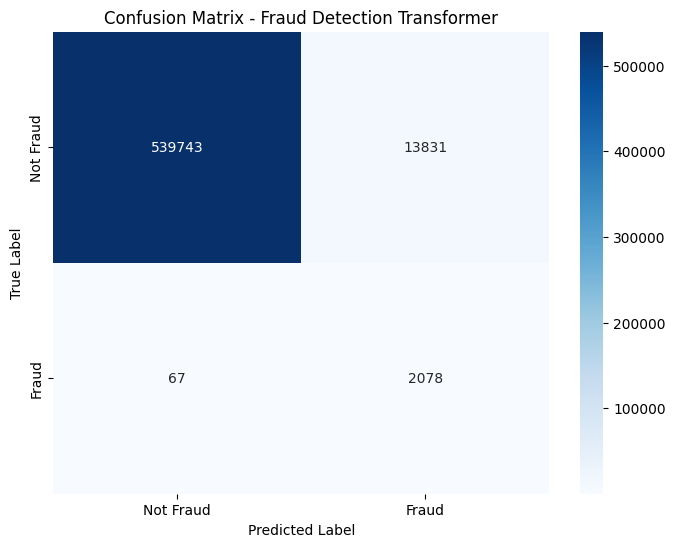

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(all_actuals, all_predictions)

# Plotting the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Fraud', 'Fraud'],
            yticklabels=['Not Fraud', 'Fraud'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Fraud Detection Transformer')
plt.show()

## Model Summary

This notebook implements and trains a **Transformer-based Classifier** for fraud detection on tabular data.

### Model Architecture (`TransformerClassifier`):
The model is built upon a custom Transformer architecture tailored for mixed tabular data, consisting of:
1.  **Tabular Input Embedding (`TabularInputEmbedding`)**: This custom layer processes the raw tabular features (`trans_hour`, `category`, `amt_log`).
    *   `trans_hour` and `category` (categorical features) are converted into dense embeddings using `nn.Embedding`.
    *   `amt_log` (numerical feature) is projected into an embedding space using a linear layer.
    *   These three feature embeddings are then stacked to form a sequence, effectively treating each feature as a 'token' in the Transformer's input sequence.
2.  **Positional Encoding (`PostionalEncoding`)**: Standard sinusoidal positional encodings are added to the sequence of embeddings to incorporate the order of features (though for fixed tabular data, this primarily provides distinct feature representations).
3.  **Encoder (`Encoder`)**: The core of the Transformer, consisting of `N` (2 in this case) `EncoderBlock` layers. Each `EncoderBlock` contains:
    *   A `MultiHeadAttentionBlock` for capturing relationships between the different embedded features.
    *   A `FeedForwardBlock` for non-linear transformations.
    *   `ResidualConnections` and `LayerNormalization` for stable training.
4.  **Classification Head**: After the `Encoder`, a mean pooling strategy is applied across the sequence dimension to condense the sequence of feature representations into a single fixed-size vector. This vector is then passed through a two-layer neural network with a ReLU activation and dropout, culminating in a final linear layer that outputs a single logit for binary classification (fraud/not fraud).

### Training Strategy:
*   **Class Imbalance Handling**: To address the severe class imbalance typical in fraud detection, **Random Undersampling** was applied to the training dataset (`df_train`). This balanced the number of fraud and non-fraud samples in the training data, preventing the model from being biased towards the majority class.
*   **Loss Function**: `nn.BCEWithLogitsLoss` was used, which combines a sigmoid activation and binary cross-entropy loss, suitable for binary classification with logits.
*   **Optimizer**: The `Adam` optimizer with a learning rate of `0.0001` was used.
*   **Epochs**: The model was trained for 20 epochs.

### Performance:
After training with the undersampled data, the model achieved the following performance on the full test dataset (`df_test`):

```
              precision    recall  f1-score   support

   Not Fraud       1.00      0.98      0.99    553574
       Fraud       0.14      0.96      0.24      2145

    accuracy                           0.98    555719
   macro avg       0.57      0.97      0.61    555719
weighted avg       1.00      0.98      0.99    555719
```

Key observations from the classification report:
*   **High Recall for Fraud (0.96)**: The model is highly effective at identifying actual fraudulent transactions, indicating a low rate of false negatives (missing fraud).
*   **Low Precision for Fraud (0.14)**: While it catches most fraud, it also has a high number of false positives (classifying non-fraud as fraud). This is often a trade-off in fraud detection, where catching more fraud is prioritized.
*   **High Overall Accuracy (0.98)**: This is largely influenced by the dominant 'Not Fraud' class, which is predicted with very high precision and recall.
*   **Accuracy on Fraud Cases (95.99%)**: A specific test on only fraud cases from the test dataset confirms the model's strong ability to identify fraud when it is present.

In summary, the model successfully leverages a Transformer architecture to learn patterns in tabular fraud data, demonstrating a strong capability to recall fraudulent transactions, which is crucial in such a domain.